In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hdg_postprocess.formats import load_from_file
import scipy.io

In [14]:

def find_element_on_boundary(R,Z,mesh):

    distances = np.sqrt((mesh._vertices_boundary_gauss[:,:,0]-R)**2 + 
                        (mesh._vertices_boundary_gauss[:,:,1]-Z)**2)
    # Find the index of the minimum distance
    min_index = np.where(distances == np.min(distances))
    return min_index[0][0]

In [2]:
solpath = './data/solutions/power_balance_boundary_checks/'
solname = 'solution_west_no_heating_no_cooling_factor'

In [3]:
sol=load_from_file.load_HDG_solution_from_file(solpath,solname)

In [4]:
ref_elem = scipy.io.loadmat('./data/reference_elements/reference_triangle_P8.mat')
name = 'refEl'
ref_dic = {}
ref_dic['IPcoordinates'] = ref_elem[name][0,0][0]  # gauss 2D points coordinates
ref_dic['IPweights'] = ref_elem[name][0,0][1][:,0]  # gauss points 2D integration weights
ref_dic['N'] = ref_elem[name][0,0][2]  # Shape functions 2D from nodal elements to Gauss points
ref_dic['Nxi'] = ref_elem[name][0,0][3]  # Derivative by xi shape functions 2D from nodal elements to Gauss points
ref_dic['Neta'] = ref_elem[name][0,0][4]  # Derivative by eta shape functions 2D from nodal elements to Gauss points
ref_dic['IPcoordinates1d'] = ref_elem[name][0,0][5]  # gauss 1D points coordinates
ref_dic['IPweights1d'] = ref_elem[name][0,0][6]  # gauss points 1D integration weights
ref_dic['N1d'] = ref_elem[name][0,0][7]  # Shape functions 1D from nodal elements to Gauss points
ref_dic['N1dxi'] = ref_elem[name][0,0][8]  # Derivative by xi shape functions 1D from nodal elements to Gauss points
ref_dic['faceNodes'] = ref_elem[name][0,0][9] -1 # connectivity for face elements
ref_dic['innerNodes'] = ref_elem[name][0,0][10] 
ref_dic['faceNodes1d'] = ref_elem[name][0,0][11] -1
ref_dic['NodesCoord'] = ref_elem[name][0,0][12] 
ref_dic['NodesCoord1d'] = ref_elem[name][0,0][13] 
ref_dic['degree'] = ref_elem[name][0,0][14] 
#ref_dic['elemType'] = ref_elem[name][0,0][15] 
sol.mesh.reference_element = ref_dic

In [5]:
atomic_data = './data/atomic/'

In [6]:
alpha_iz  = np.load(f'{atomic_data}/alpha_iz.npy')

iz_param = {}
iz_param['database'] = "AMJUEL 2.1.5JH"
iz_param['alpha'] = alpha_iz
iz_param['te_min'] = 0.1
iz_param['te_max'] = 2e4
iz_param['ne_min'] = 1e14
iz_param['ne_max'] = 1e22

alpha_rec = np.load(f'{atomic_data}/alpha_rec_2.1.8JH.npy')
rec_param = {}
rec_param['database'] = "AMJUEL 2.1.8JH"
rec_param['alpha'] = alpha_rec
rec_param['te_min'] = 0.1
rec_param['te_max'] = 2e4
rec_param['ne_min'] = 1e14
rec_param['ne_max'] = 1e22


alpha_cx = np.array([-1.87744894e+01,  4.51800000e-01, -3.58100000e-02,  8.00400000e-03, -6.83700000e-04])
cx_param = {}
cx_param['database'] = "OpenADAS expanded"
cx_param['alpha'] = alpha_cx
cx_param['te_min'] = 0.1
cx_param['te_max'] = 2e4

alpha_Eiz = np.load(f'{atomic_data}/alpha_energy_iz.npy')
Eiz_param = {}
Eiz_param['database'] = "AMJUEL 2.1.5JH"
Eiz_param['alpha'] = alpha_Eiz
Eiz_param['te_min'] = 0.1
Eiz_param['te_max'] = 2e4
Eiz_param['ne_min'] = 1e14
Eiz_param['ne_max'] = 1e22

alpha_Erec = np.load(f'{atomic_data}/alpha_energy_rec.npy')
Erec_param = {}
Erec_param['database'] = "AMJUEL 2.1.8JH"
Erec_param['alpha'] = alpha_Erec
Erec_param['te_min'] = 0.1
Erec_param['te_max'] = 2e4
Erec_param['ne_min'] = 1e14
Erec_param['ne_max'] = 1e22



atomic = {}
atomic['iz'] = iz_param
atomic['cx'] = cx_param
atomic['rec'] = rec_param
atomic['Eiz'] = Eiz_param
atomic['Erec'] = Erec_param




In [7]:
diff_nn_params = {}
diff_nn_params['const'] = False
diff_nn_params['dnn_soft'] = True
diff_nn_params['dnn_max'] = 2e8
diff_nn_params['dnn_min'] = 3.
diff_nn_params['dnn_w'] = 0.01
diff_nn_params['dnn_width'] = 10
diff_nn_params['ti_soft'] = True
diff_nn_params['ti_min'] = 1e-6
diff_nn_params['ti_w'] = 0.01
diff_nn_params['ti_width'] = 10

In [8]:
sol.atomic_parameters=atomic
sol.dnn_parameters=diff_nn_params
sol.parameters['physics']['R_E'] = 0. #solution from recent version

In [10]:
sol.calculate_boundary_summary()
boundary_summary = sol.summary.boundary.boundary_summary

In [11]:
r_low = 1.9091
z_low = -0.5798
r_high = 2.446
z_high = -0.7964

Full mesh is plotted includin curved edges


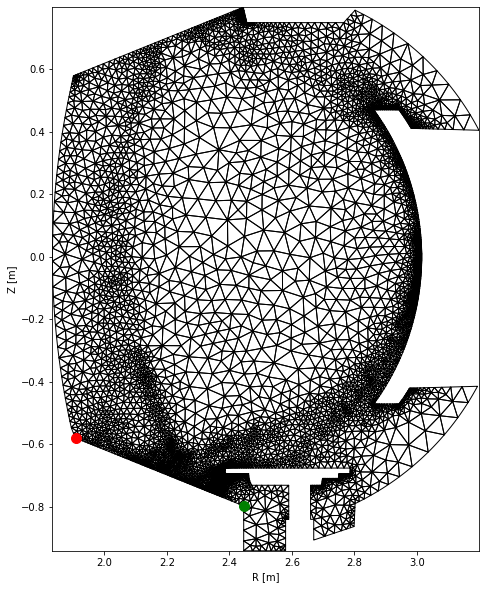

In [12]:
fig,ax = plt.subplots(figsize=(10,10))
sol.mesh.plot_full_mesh(ax=ax)
plt.scatter(r_low,z_low,color='red',s=100)
plt.scatter(r_high,z_high,color='green',s=100)

In [15]:
element_low_hfs = find_element_on_boundary(r_low, z_low, sol.mesh)
element_high_hfs = find_element_on_boundary(r_high, z_high, sol.mesh)
element_low_hfs, element_high_hfs

(630, 715)

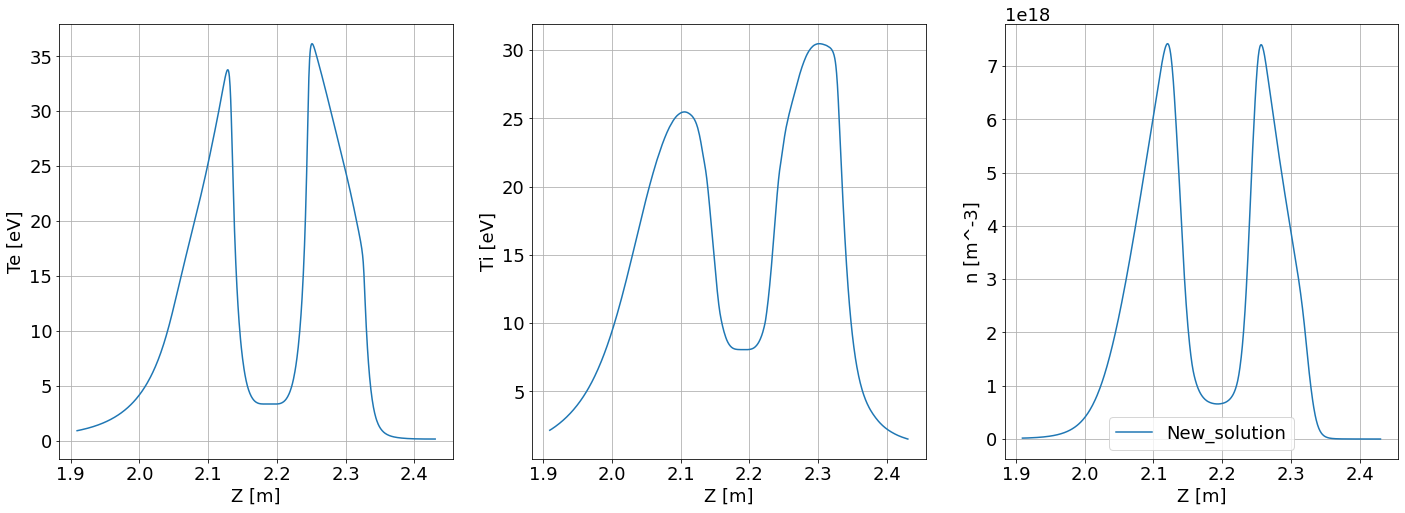

In [16]:
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(1,3, figsize=(24,8))
axes[0].plot(boundary_summary['r'][element_low_hfs:element_high_hfs].flatten(), boundary_summary['te'][element_low_hfs:element_high_hfs].flatten())

axes[0].grid()

axes[1].plot(boundary_summary['r'][element_low_hfs:element_high_hfs].flatten(), boundary_summary['ti'][element_low_hfs:element_high_hfs].flatten())

axes[1].grid()


axes[2].plot(boundary_summary['r'][element_low_hfs:element_high_hfs].flatten(), boundary_summary['n'][element_low_hfs:element_high_hfs].flatten())

axes[2].grid()

axes[0].set_ylabel('Te [eV]')
axes[1].set_ylabel('Ti [eV]')
axes[2].set_ylabel('n [m^-3]')
axes[0].set_xlabel('Z [m]')
axes[1].set_xlabel('Z [m]')
axes[2].set_xlabel('Z [m]')
plt.legend(['New_solution','Old_solution'])

